<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_12_1_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 12: Explainability**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 12 Material

* **Part 12.1: What is Explainability** [[Notebook]](t81_558_class_12_1_explainability.ipynb)
* Part 12.2: Feature Importance [[Notebook]](t81_558_class_12_2_feature_importance.ipynb)
* Part 12.3: Visualization for Computer Vision [[Notebook]](t81_558_class_12_3_vision_viz.ipynb)
* Part 12.4: Gradient-Based Explanations [[Notebook]](t81_558_class_12_4_gradient_explain.ipynb)
* Part 12.5: Limitations of Explainability [[Notebook]](t81_558_class_12_5_limitations.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 12.1: What is Explainability

A deep neural network can reach an answer with remarkable accuracy while offering no account of *why*. The model is a stack of matrix multiplications and nonlinearities with millions of parameters, and nothing about that arithmetic is meaningful to a human on its face. This is the black-box problem, and it sits at the center of a growing field known as **explainable AI** (often abbreviated XAI). The goal of explainability is to make a model's behavior understandable to people, whether to build trust, to debug a failure, to satisfy a regulation, or to learn something new from what the model has discovered.

The need is practical, not philosophical. A physician will not act on a cancer prediction they cannot interrogate. A bank that denies a loan may be legally required to state why; regulations such as the European Union's GDPR grant individuals a right to an explanation of automated decisions. An engineer debugging a model that fails on certain inputs needs to know what the network is keying on. And a scientist using a model to study a phenomenon wants the model's insight, not just its output. In each case, the prediction alone is not enough.

This module surveys the main techniques for explaining neural networks. This first section frames the problem: it distinguishes the kinds of explanation, introduces the vocabulary the field uses, and demonstrates the cleanest case of all, a model so simple that it explains itself. The sections that follow tackle the harder and more common case of explaining a genuine black box, first for tabular models through feature importance, then for image models through visualization and gradient-based methods, and finally a candid look at where all of these techniques fall short.

## Interpretability and Explainability

Two terms recur throughout this field, and although people use them loosely, a useful distinction exists. **Interpretability** usually refers to the degree to which a model's mechanics are inherently understandable. A model is interpretable when a person can, in principle, follow how it turns inputs into outputs. **Explainability** usually refers to methods that produce human-understandable accounts of a model's behavior *after the fact*, especially for models that are not interpretable on their own.

A linear regression is interpretable: each coefficient states exactly how the output responds to a feature. A deep network is not interpretable in that sense, so we reach for explainability techniques that approximate or probe its behavior. The distinction matters because the two paths have different costs. An interpretable model gives you understanding for free but may sacrifice accuracy on complex problems. A black-box model may be more accurate, but every explanation you extract from it is an approximation, with the limitations that come with approximating.

## A Taxonomy of Explanation Methods

The many techniques in this field are easier to navigate once you can place each one along a few axes. Three distinctions cover most of the landscape.

* **Global versus local.** A *global* explanation describes the behavior of the model as a whole: which features it relies on across all inputs, or what patterns it has learned in general. A *local* explanation accounts for a single prediction: why *this* image was labeled a dog, or why *this* applicant was denied. Feature importance is often global; a saliency map for one image is local.

* **Intrinsic versus post-hoc.** An *intrinsic* explanation comes from a model that is interpretable by design, such as a linear model or a shallow decision tree. A *post-hoc* explanation is produced after training by a separate procedure applied to an already-trained black box. Almost everything in this module is post-hoc, because deep networks are not intrinsically interpretable.

* **Model-specific versus model-agnostic.** A *model-specific* method exploits the internals of a particular architecture, such as reading a CNN's convolutional filters. A *model-agnostic* method treats the model as a function it can only query, which makes it applicable to any model. Permutation feature importance, covered next, is model-agnostic; Grad-CAM is model-specific to convolutional networks.

These axes are not mutually exclusive, and a given technique occupies a point on each. Keeping them in mind helps you choose a method that matches the question you are actually asking.

## The Glass Box: Models That Explain Themselves

The simplest form of explanation requires no special technique at all, because some models are transparent by construction. A logistic regression computes a weighted sum of its input features and passes it through a sigmoid. Each weight is the explanation: it states the direction and strength of that feature's influence on the prediction. If the inputs are standardized to a common scale, the weights are directly comparable, and sorting them ranks the features by importance.

To make this concrete, and to set up a contrast with the black-box methods in the rest of the module, we train two models on the same medical dataset. The Wisconsin breast cancer dataset provides thirty numeric features computed from cell-nucleus images, and the task is to classify each tumor as malignant or benign. The first model is a logistic regression, which in PyTorch is nothing more than a single `Linear` layer. The second is a multi-layer network, a genuine black box. We will see that the black box matches or exceeds the accuracy of the glass box, which is exactly why black boxes are worth using, and exactly why we need the explanation methods that follow.

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0)
np.random.seed(0)

data = load_breast_cancer()
feature_names = data.feature_names
X_tr, X_te, y_tr, y_te = train_test_split(
    data.data, data.target, test_size=0.3, random_state=0, stratify=data.target)

# Standardize so the linear model's weights are directly comparable.
scaler = StandardScaler().fit(X_tr)
X_tr_t = torch.tensor(scaler.transform(X_tr), dtype=torch.float32)
X_te_t = torch.tensor(scaler.transform(X_te), dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
y_te_t = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)


def train(model, epochs=300):
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    loss_fn = nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X_tr_t), y_tr_t)
        loss.backward()
        opt.step()
    return model


def accuracy(model):
    with torch.no_grad():
        pred = (torch.sigmoid(model(X_te_t)) >= 0.5).float()
    return (pred == y_te_t).float().mean().item()


# Glass box: logistic regression is a single Linear layer.
glass_box = train(nn.Linear(30, 1))

# Black box: a multi-layer network.
black_box = train(nn.Sequential(
    nn.Linear(30, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1),
))

print(f"Glass box (logistic regression) accuracy: {accuracy(glass_box):.3f}")
print(f"Black box (neural network)      accuracy: {accuracy(black_box):.3f}")

Glass box (logistic regression) accuracy: 0.953
Black box (neural network)      accuracy: 0.953


Both models classify the tumors accurately, with the black box matching or slightly exceeding the linear model. The difference is that we can read the glass box directly. Its thirty weights, one per feature, *are* its explanation: because the inputs were standardized, a large positive weight means that higher values of that feature push the prediction toward the positive class (benign, encoded as 1), while a large negative weight pushes toward malignant. Sorting the weights by magnitude tells us which measurements the model considers most decisive.

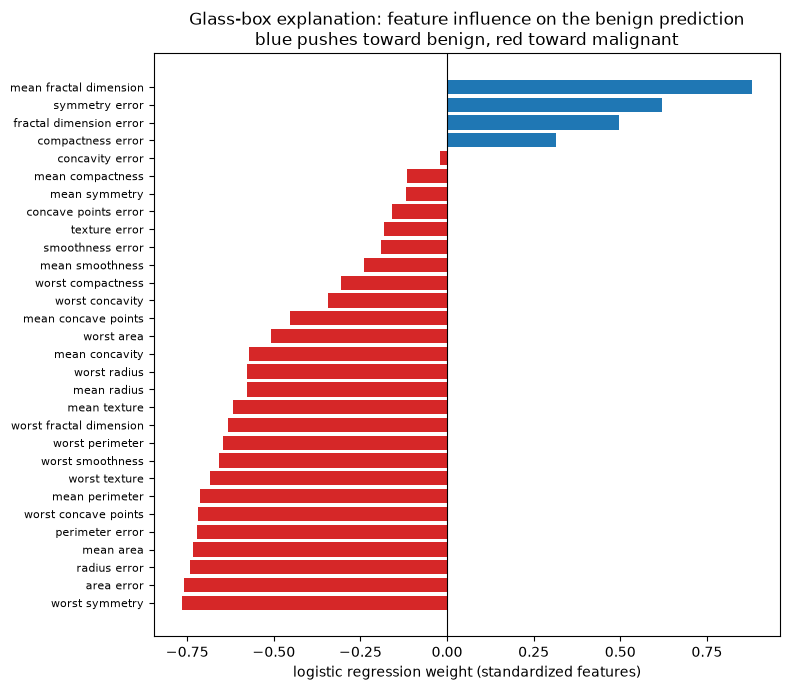

In [3]:
# The linear model's weights are its explanation. Sort features by influence.
weights = glass_box.weight.detach().numpy().ravel()
order = np.argsort(weights)

plt.figure(figsize=(8, 7))
colors = ["tab:red" if w < 0 else "tab:blue" for w in weights[order]]
plt.barh(range(30), weights[order], color=colors)
plt.yticks(range(30), [feature_names[i] for i in order], fontsize=8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("logistic regression weight (standardized features)")
plt.title("Glass-box explanation: feature influence on the benign prediction\n"
          "blue pushes toward benign, red toward malignant")
plt.tight_layout()
plt.show()

The chart is a complete, exact explanation of the logistic regression. Features such as the various "worst" measurements of tumor size and shape carry the largest negative weights, pushing predictions toward malignant, which aligns with medical intuition that larger, more irregular nuclei indicate cancer. Nothing about this explanation is approximate; it is simply a readout of the model's parameters.

The catch is that this luxury disappears the moment we use a model powerful enough to be interesting. The black-box network reached the same accuracy, but it has thousands of weights spread across three layers, and no single weight corresponds to a feature's overall influence. To explain *it*, we need post-hoc, often model-agnostic techniques that probe the trained model from the outside. The next section introduces the most widely used of these for tabular models: [Feature Importance](t81_558_class_12_2_feature_importance.ipynb).